# SSL-HAR Model Zoo - Inference & Fine-tuning Notebook

**Paper:** Benchmarking Encoders and Self-Supervised Learning for Smartphone-Based Human Activity Recognition  
Da Luz, Soto, Napoli, Rocha, Boccato, Borin — IEEE Access 2026  
DOI: [10.1109/ACCESS.2026.3669412](https://doi.org/10.1109/ACCESS.2026.3669412)  
**Code:** https://github.com/H-IAAC/benchmarking-encoders-ssl-har

---

This notebook lets you:
1. **Evaluate** a finetuned checkpoint directly (no training needed)
2. **Fine-tune** a pretrained checkpoint on labeled data and then evaluate

Just fill in the configuration cell below and run all cells in order.


## 1. Install requirements

In [1]:
!pip install minerva kaleido==0.2.1 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.2/219.2 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.3/216.3 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 132.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 64.6 MB/s eta 0:00:00


## 2. Model Zoo Registry

This cell contains the complete registry mapping every available model to its direct Zenodo download URL.  
**You do not need to edit this cell.** It is updated as new models are added to the zoo.


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MODEL ZOO REGISTRY
#  Maps (ssl_method, encoder, dataset, role) → direct Zenodo URL
#  All files: https://zenodo.org/records/19301058
# ═══════════════════════════════════════════════════════════════════════════════

_BASE = "https://zenodo.org/records/19301058/files"

def _url(name): return f"{_BASE}/{name}"

MODEL_ZOO = {
    # ── KuHar ──────────────────────────────────────────────────────────────────
    ("tfc",  "cnnpff",         "kh", "pretrained"): _url("tfc_cnnpff_kh_pretrained.ckpt"),
    ("tfc",  "cnnpff",         "kh", "finetuned"):  _url("tfc_cnnpff_kh_finetuned.ckpt"),
    ("lfr",  "imutransformer", "kh", "pretrained"): _url("lfr_imutransformer_kh_pretrained.ckpt"),
    ("lfr",  "imutransformer", "kh", "finetuned"):  _url("lfr_imutransformer_kh_finetuned.ckpt"),
    ("diet", "resnetse5",      "kh", "pretrained"): _url("diet_resnetse5_kh_pretrained.ckpt"),
    ("diet", "resnetse5",      "kh", "finetuned"):  _url("diet_resnetse5_kh_finetuned.ckpt"),
    ("tfc",  "rnn",            "kh", "pretrained"): _url("tfc_rnn_kh_pretrained.ckpt"),
    ("tfc",  "rnn",            "kh", "finetuned"):  _url("tfc_rnn_kh_finetuned.ckpt"),
    ("tfc",  "ts2vec",         "kh", "pretrained"): _url("tfc_ts2vec_kh_pretrained.ckpt"),
    ("tfc",  "ts2vec",         "kh", "finetuned"):  _url("tfc_ts2vec_kh_finetuned.ckpt"),
    ("tfc",  "tstcc",          "kh", "pretrained"): _url("tfc_tstcc_kh_pretrained.ckpt"),
    ("tfc",  "tstcc",          "kh", "finetuned"):  _url("tfc_tstcc_kh_finetuned.ckpt"),

    # ── MotionSense ────────────────────────────────────────────────────────────
    ("tfc",  "cnnpff",         "ms", "pretrained"): _url("tfc_cnnpff_ms_pretrained.ckpt"),
    ("tfc",  "cnnpff",         "ms", "finetuned"):  _url("tfc_cnnpff_ms_finetuned.ckpt"),
    ("tfc",  "imutransformer", "ms", "pretrained"): _url("tfc_imutransformer_ms_pretrained.ckpt"),
    ("tfc",  "imutransformer", "ms", "finetuned"):  _url("tfc_imutransformer_ms_finetuned.ckpt"),
    ("lfr",  "resnetse5",      "ms", "pretrained"): _url("lfr_resnetse5_ms_pretrained.ckpt"),
    ("lfr",  "resnetse5",      "ms", "finetuned"):  _url("lfr_resnetse5_ms_finetuned.ckpt"),
    ("tfc",  "rnn",            "ms", "pretrained"): _url("tfc_rnn_ms_pretrained.ckpt"),
    ("tfc",  "rnn",            "ms", "finetuned"):  _url("tfc_rnn_ms_finetuned.ckpt"),
    ("lfr",  "ts2vec",         "ms", "pretrained"): _url("lfr_ts2vec_ms_pretrained.ckpt"),
    ("lfr",  "ts2vec",         "ms", "finetuned"):  _url("lfr_ts2vec_ms_finetuned.ckpt"),
    ("lfr",  "tstcc",          "ms", "pretrained"): _url("lfr_tstcc_ms_pretrained.ckpt"),
    ("lfr",  "tstcc",          "ms", "finetuned"):  _url("lfr_tstcc_ms_finetuned.ckpt"),

    # ── RealWorld Thigh ────────────────────────────────────────────────────────
    ("tfc",  "cnnpff",         "rwthigh", "pretrained"): _url("tfc_cnnpff_rwthigh_pretrained.ckpt"),
    ("tfc",  "cnnpff",         "rwthigh", "finetuned"):  _url("tfc_cnnpff_rwthigh_finetuned.ckpt"),
    ("lfr",  "imutransformer", "rwthigh", "pretrained"): _url("lfr_imutransformer_rwthigh_pretrained.ckpt"),
    ("lfr",  "imutransformer", "rwthigh", "finetuned"):  _url("lfr_imutransformer_rwthigh_finetuned.ckpt"),
    ("tfc",  "resnetse5",      "rwthigh", "pretrained"): _url("tfc_resnetse5_rwthigh_pretrained.ckpt"),
    ("tfc",  "resnetse5",      "rwthigh", "finetuned"):  _url("tfc_resnetse5_rwthigh_finetuned.ckpt"),
    ("tfc",  "rnn",            "rwthigh", "pretrained"): _url("tfc_rnn_rwthigh_pretrained.ckpt"),
    ("tfc",  "rnn",            "rwthigh", "finetuned"):  _url("tfc_rnn_rwthigh_finetuned.ckpt"),
    ("tfc",  "ts2vec",         "rwthigh", "pretrained"): _url("tfc_ts2vec_rwthigh_pretrained.ckpt"),
    ("tfc",  "ts2vec",         "rwthigh", "finetuned"):  _url("tfc_ts2vec_rwthigh_finetuned.ckpt"),
    ("lfr",  "tstcc",          "rwthigh", "pretrained"): _url("lfr_tstcc_rwthigh_pretrained.ckpt"),
    ("lfr",  "tstcc",          "rwthigh", "finetuned"):  _url("lfr_tstcc_rwthigh_finetuned.ckpt"),

    # ── RealWorld Waist ────────────────────────────────────────────────────────
    ("tfc",  "cnnpff",         "rwwaist", "pretrained"): _url("tfc_cnnpff_rwwaist_pretrained.ckpt"),
    ("tfc",  "cnnpff",         "rwwaist", "finetuned"):  _url("tfc_cnnpff_rwwaist_finetuned.ckpt"),
    ("lfr",  "imutransformer", "rwwaist", "pretrained"): _url("lfr_imutransformer_rwwaist_pretrained.ckpt"),
    ("lfr",  "imutransformer", "rwwaist", "finetuned"):  _url("lfr_imutransformer_rwwaist_finetuned.ckpt"),
    ("tfc",  "resnetse5",      "rwwaist", "pretrained"): _url("tfc_resnetse5_rwwaist_pretrained.ckpt"),
    ("tfc",  "resnetse5",      "rwwaist", "finetuned"):  _url("tfc_resnetse5_rwwaist_finetuned.ckpt"),
    ("tfc",  "rnn",            "rwwaist", "pretrained"): _url("tfc_rnn_rwwaist_pretrained.ckpt"),
    ("tfc",  "rnn",            "rwwaist", "finetuned"):  _url("tfc_rnn_rwwaist_finetuned.ckpt"),
    ("tfc",  "ts2vec",         "rwwaist", "pretrained"): _url("tfc_ts2vec_rwwaist_pretrained.ckpt"),
    ("tfc",  "ts2vec",         "rwwaist", "finetuned"):  _url("tfc_ts2vec_rwwaist_finetuned.ckpt"),
    ("tfc",  "tstcc",          "rwwaist", "pretrained"): _url("tfc_tstcc_rwwaist_pretrained.ckpt"),
    ("tfc",  "tstcc",          "rwwaist", "finetuned"):  _url("tfc_tstcc_rwwaist_finetuned.ckpt"),

    # ── UCI-HAR ────────────────────────────────────────────────────────────────
    ("tfc",  "cnnpff",         "uci", "pretrained"): _url("tfc_cnnpff_uci_pretrained.ckpt"),
    ("tfc",  "cnnpff",         "uci", "finetuned"):  _url("tfc_cnnpff_uci_finetuned.ckpt"),
    ("tfc",  "imutransformer", "uci", "pretrained"): _url("tfc_imutransformer_uci_pretrained.ckpt"),
    ("tfc",  "imutransformer", "uci", "finetuned"):  _url("tfc_imutransformer_uci_finetuned.ckpt"),
    ("diet", "resnetse5",      "uci", "pretrained"): _url("diet_resnetse5_uci_pretrained.ckpt"),
    ("diet", "resnetse5",      "uci", "finetuned"):  _url("diet_resnetse5_uci_finetuned.ckpt"),
    ("tfc",  "rnn",            "uci", "pretrained"): _url("tfc_rnn_uci_pretrained.ckpt"),
    ("tfc",  "rnn",            "uci", "finetuned"):  _url("tfc_rnn_uci_finetuned.ckpt"),
    ("tfc",  "ts2vec",         "uci", "pretrained"): _url("tfc_ts2vec_uci_pretrained.ckpt"),
    ("tfc",  "ts2vec",         "uci", "finetuned"):  _url("tfc_ts2vec_uci_finetuned.ckpt"),
    ("tfc",  "tstcc",          "uci", "pretrained"): _url("tfc_tstcc_uci_pretrained.ckpt"),
    ("tfc",  "tstcc",          "uci", "finetuned"):  _url("tfc_tstcc_uci_finetuned.ckpt"),

    # ── WISDM ──────────────────────────────────────────────────────────────────
    ("tfc",  "cnnpff",         "wisdm", "pretrained"): _url("tfc_cnnpff_wisdm_pretrained.ckpt"),
    ("tfc",  "cnnpff",         "wisdm", "finetuned"):  _url("tfc_cnnpff_wisdm_finetuned.ckpt"),
    ("tfc",  "imutransformer", "wisdm", "pretrained"): _url("tfc_imutransformer_wisdm_pretrained.ckpt"),
    ("tfc",  "imutransformer", "wisdm", "finetuned"):  _url("tfc_imutransformer_wisdm_finetuned.ckpt"),
    ("tfc",  "resnetse5",      "wisdm", "pretrained"): _url("tfc_resnetse5_wisdm_pretrained.ckpt"),
    ("tfc",  "resnetse5",      "wisdm", "finetuned"):  _url("tfc_resnetse5_wisdm_finetuned.ckpt"),
    ("tfc",  "rnn",            "wisdm", "pretrained"): _url("tfc_rnn_wisdm_pretrained.ckpt"),
    ("tfc",  "rnn",            "wisdm", "finetuned"):  _url("tfc_rnn_wisdm_finetuned.ckpt"),
    ("tfc",  "ts2vec",         "wisdm", "pretrained"): _url("tfc_ts2vec_wisdm_pretrained.ckpt"),
    ("tfc",  "ts2vec",         "wisdm", "finetuned"):  _url("tfc_ts2vec_wisdm_finetuned.ckpt"),
    ("tfc",  "tstcc",          "wisdm", "pretrained"): _url("tfc_tstcc_wisdm_pretrained.ckpt"),
    ("tfc",  "tstcc",          "wisdm", "finetuned"):  _url("tfc_tstcc_wisdm_finetuned.ckpt"),
}

# Best accuracy per (ssl, encoder, dataset) — from paper Table III
BEST_RESULTS = {
    ("tfc",  "ts2vec",         "kh"):      90.3,
    ("tfc",  "cnnpff",         "kh"):      81.2,
    ("diet", "resnetse5",      "kh"):      80.6,
    ("lfr",  "imutransformer", "kh"):      77.1,
    ("tfc",  "rnn",            "kh"):      74.3,
    ("tfc",  "tstcc",          "kh"):      73.6,
    ("lfr",  "ts2vec",         "ms"):      97.5,
    ("tfc",  "cnnpff",         "ms"):      95.0,
    ("lfr",  "resnetse5",      "ms"):      93.8,
    ("lfr",  "tstcc",          "ms"):      92.8,
    ("tfc",  "rnn",            "ms"):      92.0,
    ("tfc",  "imutransformer", "ms"):      89.7,
    ("tfc",  "resnetse5",      "rwthigh"): 82.8,
    ("tfc",  "cnnpff",         "rwthigh"): 81.5,
    ("tfc",  "ts2vec",         "rwthigh"): 81.2,
    ("tfc",  "rnn",            "rwthigh"): 81.0,
    ("lfr",  "tstcc",          "rwthigh"): 74.9,
    ("lfr",  "imutransformer", "rwthigh"): 72.2,
    ("tfc",  "ts2vec",         "rwwaist"): 82.5,
    ("tfc",  "rnn",            "rwwaist"): 82.1,
    ("tfc",  "cnnpff",         "rwwaist"): 81.8,
    ("lfr",  "imutransformer", "rwwaist"): 80.1,
    ("tfc",  "resnetse5",      "rwwaist"): 79.2,
    ("tfc",  "tstcc",          "rwwaist"): 76.5,
    ("tfc",  "cnnpff",         "uci"):     96.2,
    ("tfc",  "ts2vec",         "uci"):     96.1,
    ("diet", "resnetse5",      "uci"):     95.9,
    ("tfc",  "rnn",            "uci"):     94.9,
    ("tfc",  "tstcc",          "uci"):     94.3,
    ("tfc",  "imutransformer", "uci"):     92.3,
    ("tfc",  "cnnpff",         "wisdm"):   91.2,
    ("tfc",  "ts2vec",         "wisdm"):   90.7,
    ("tfc",  "rnn",            "wisdm"):   89.2,
    ("tfc",  "imutransformer", "wisdm"):   89.2,
    ("tfc",  "tstcc",          "wisdm"):   88.9,
    ("tfc",  "resnetse5",      "wisdm"):   86.9,
}

def list_available_models():
    """Print all models currently in the zoo."""
    header = f"{'SSL':<8} {'Encoder':<16} {'Dataset':<10} {'Role':<12} {'Accuracy':>10}"
    print(header)
    print("─" * len(header))
    seen = set()
    for (ssl, enc, ds, role), url in sorted(MODEL_ZOO.items()):
        if (ssl, enc, ds) not in seen:
            acc = BEST_RESULTS.get((ssl, enc, ds), None)
            acc_str = f"{acc:.1f}%" if acc else "—"
            print(f"{ssl.upper():<8} {enc:<16} {ds:<10} {'both':<12} {acc_str:>10}")
            seen.add((ssl, enc, ds))

list_available_models()

SSL      Encoder          Dataset    Role           Accuracy
────────────────────────────────────────────────────────────
DIET     resnetse5        kh         both              80.6%
DIET     resnetse5        uci        both              95.9%
LFR      imutransformer   kh         both              77.1%
LFR      imutransformer   rwthigh    both              72.2%
LFR      imutransformer   rwwaist    both              80.1%
LFR      resnetse5        ms         both              93.8%
LFR      ts2vec           ms         both              97.5%
LFR      tstcc            ms         both              92.8%
LFR      tstcc            rwthigh    both              74.9%
TFC      cnnpff           kh         both              81.2%
TFC      cnnpff           ms         both              95.0%
TFC      cnnpff           rwthigh    both              81.5%
TFC      cnnpff           rwwaist    both              81.8%
TFC      cnnpff           uci        both              96.2%
TFC      cnnpff         

## 3. Configuration

Edit the variables below, then run all remaining cells.


## 4. Resolve download URL and local paths

In [254]:
# ─────────────────────────────────────────────────────────────────
#  CONFIGURATION — edit this cell only
# ─────────────────────────────────────────────────────────────────

# ── Model selection ───────────────────────────────────────────────
# Must match a key in MODEL_ZOO above.
# SSL method: "lfr" | "tfc" | "tnc" | "diet"
SSL_METHOD   = "lfr"

# Encoder:    "ts2vec" | "cnnpff" | "resnetse5" | "rnn" | "tstcc" | "imutransformer"
ENCODER      = "ts2vec"

# Dataset the model was trained on: "ms" | "uci" | "kh" | "rwthigh" | "rwwaist" | "wisdm"
TRAIN_DATASET = "ms"

# ── Mode ──────────────────────────────────────────────────────────
# "evaluate"  → download finetuned checkpoint and run test set
# "finetune"  → download pretrained checkpoint, fine-tune, then evaluate
MODE = "evaluate"   # "evaluate" | "finetune"

# ── Fine-tuning options (only used when MODE = "finetune") ────────
FINETUNE_STRATEGY = "full"   # "full" (entire model) | "freeze" (head only)
FINETUNE_EPOCHS   = 100
FINETUNE_LR       = None     # None → uses paper default for this encoder

# ── Evaluation dataset ────────────────────────────────────────────
# Usually same as TRAIN_DATASET; change to test cross-dataset transfer.
EVAL_DATASET = "ms"   # "ms" | "uci" | "kh" | "rwthigh" | "rwwaist" | "wisdm"

# ── Hardware ──────────────────────────────────────────────────────
ACCELERATOR = "auto"   # "auto" | "cpu" | "gpu"
NUM_WORKERS  = 4
BATCH_SIZE   = 64
# ─────────────────────────────────────────────────────────────────


In [255]:
from datetime import datetime
from pathlib import Path

# Determine which role to download
role = "finetuned" if MODE == "evaluate" else "pretrained"
zoo_key = (SSL_METHOD, ENCODER, TRAIN_DATASET, role)

if zoo_key not in MODEL_ZOO:
    available = [k for k in MODEL_ZOO if k[:3] == (SSL_METHOD, ENCODER, TRAIN_DATASET)]
    raise KeyError(
        f"Model not found in zoo: {zoo_key}\n"
        f"Available roles for this combination: {available}\n"
        f"Run list_available_models() to see the full zoo."
    )

DOWNLOAD_URL      = MODEL_ZOO[zoo_key]
DOWNLOAD_FILENAME = DOWNLOAD_URL.split("/")[-1]   # e.g. lfr_ts2vec_ms_finetuned.ckpt

CKPT_DIR     = Path("checkpoints")
DATASET_PATH = Path("datasets/DAGHAR")
CKPT_DIR.mkdir(exist_ok=True)

execution_id = f"run_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
log_dir = f"./logs/{execution_id}"

print(f"Mode              : {MODE}")
print(f"SSL method        : {SSL_METHOD.upper()}")
print(f"Encoder           : {ENCODER}")
print(f"Train dataset     : {TRAIN_DATASET}")
print(f"Eval dataset      : {EVAL_DATASET}")
print(f"Downloading role  : {role}")
print(f"File              : {DOWNLOAD_FILENAME}")
print(f"URL               : {DOWNLOAD_URL}")
print(f"Execution ID      : {execution_id}")


Mode              : evaluate
SSL method        : LFR
Encoder           : ts2vec
Train dataset     : ms
Eval dataset      : ms
File              : lfr_ts2vec_ms_finetuned.ckpt
URL               : https://zenodo.org/records/19301058/files/lfr_ts2vec_ms_finetuned.ckpt
Execution ID      : run_20260329-020226


## 5. Download checkpoint from Zenodo

In [256]:
import subprocess

local_ckpt = CKPT_DIR / DOWNLOAD_FILENAME

if local_ckpt.exists():
    print(f"Already cached: {local_ckpt}")
else:
    print(f"Downloading {DOWNLOAD_FILENAME} ...")
    result = subprocess.run(
        ["wget", "-q", "--show-progress", DOWNLOAD_URL, "-O", str(local_ckpt)],
        capture_output=False
    )
    if result.returncode != 0 or not local_ckpt.exists():
        raise RuntimeError(f"Download failed for {DOWNLOAD_URL}")

checkpoint_path = str(local_ckpt)
print(f"Checkpoint ready: {checkpoint_path}")


Already cached: checkpoints/lfr_ts2vec_ms_finetuned.ckpt
Checkpoint ready: checkpoints/lfr_ts2vec_ms_finetuned.ckpt


## 6. Imports

In [257]:
import lightning as L
import torch
import torchmetrics
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger

from minerva.data.readers.csv_reader import CSVReader
from minerva.data.datasets.base import SimpleDataset
from minerva.data.data_modules.base import MinervaDataModule
from minerva.models.loaders import FromPretrained
from minerva.models.nets.mlp import MLP
from minerva.models.nets.base import SimpleSupervisedModel
from minerva.models.nets.time_series.cnns import CNN_PF_Backbone
from minerva.models.nets.time_series.resnet import _ResNet1D, ResNetSEBlock
from minerva.models.nets.time_series.imu_transformer import _IMUTransformerEncoder
from minerva.models.nets.tnc import TSEncoder, RnnEncoder
from minerva.models.nets.lfr_har_architectures import HARSCnnEncoder
from minerva.models.ssl.tfc import TFC_Backbone
from minerva.models.adapters import MaxPoolingTransposingSqueezingAdapter
from minerva.transforms import Reshape, CastTo, TransformPipeline
from minerva.pipelines.lightning_pipeline import SimpleLightningPipeline
from minerva.analysis.model_analysis import TSNEAnalysis

## 7. Build backbone

In [258]:
def build_backbone(ssl_method: str, encoder: str):
    # Encoder architectures shared across SSL methods
    def _ts2vec():
        return TSEncoder(input_dims=6, output_dims=320, hidden_dims=64, depth=10, permute=True)
    def _cnnpff():
        return CNN_PF_Backbone(include_middle=True, flatten=True)
    def _resnetse5():
        return _ResNet1D(input_shape=[6,60],avg_pooling=True,residual_block_cls=ResNetSEBlock)
    def _rnn():
        return RnnEncoder(hidden_size=100, in_channel=6, encoding_size=320,
                          cell_type="GRU", num_layers=1, dropout=0,
                          bidirectional=True, permute=True)
    def _imutransformer():
        return _IMUTransformerEncoder(input_shape=[6, 60], transformer_dim=64,
                                      encode_position=True, nhead=8,
                                      dim_feedforward=128, transformer_dropout=0.1,
                                      transformer_activation="gelu",
                                      num_encoder_layers=6, permute=False)
    def _tstcc():
        return HARSCnnEncoder(dim=2304, input_channel=6, inner_conv_output_dim=1280)

    _ENC = {
        "ts2vec":         _ts2vec,
        "cnnpff":         _cnnpff,
        "resnetse5":      _resnetse5,
        "rnn":            _rnn,
        "imutransformer": _imutransformer,
        "tstcc":          _tstcc,
    }

    if encoder not in _ENC:
        raise ValueError(f"Unknown encoder: {encoder}")

    if ssl_method == "tfc":
        # TSEncoder (ts2vec) outputs (batch, time, features) — needs adapter inside TFC_Backbone
        tfc_adapter = MaxPoolingTransposingSqueezingAdapter(kernel_size=60) if encoder == "ts2vec" else None
        return TFC_Backbone(
            input_channels=6,
            TS_length=60,
            single_encoding_size=128,
            time_encoder=_ENC[encoder](),
            frequency_encoder=_ENC[encoder](),   # fresh instance for freq branch
            adapter=tfc_adapter,
        )

    elif ssl_method in ("lfr", "tnc", "diet"):
        return _ENC[encoder]()

    raise ValueError(f"Unknown SSL method: {ssl_method}")


base_backbone = build_backbone(SSL_METHOD, ENCODER)
print(base_backbone)

TSEncoder(
  (input_fc): Linear(in_features=6, out_features=64, bias=True)
  (feature_extractor): DilatedConvEncoder(
    (net): Sequential(
      (0): ConvBlock(
        (conv1): SamePadConv(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        )
        (conv2): SamePadConv(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        )
      )
      (1): ConvBlock(
        (conv1): SamePadConv(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        )
        (conv2): SamePadConv(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        )
      )
      (2): ConvBlock(
        (conv1): SamePadConv(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
        )
        (conv2): SamePadConv(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
        )
      )
 

## 8. Load weights into backbone

In [259]:
backbone = FromPretrained(
    model=base_backbone,
    ckpt_path=checkpoint_path,
    filter_keys=["backbone"],
    keys_to_rename={"backbone.": ""},
    strict=True,
    error_on_missing_keys=True,
)
print("Backbone loaded.")


Performing key renaming with: {'backbone.': ''}
	Renaming key: backbone.input_fc.weight -> input_fc.weight (changed: True)
	Renaming key: backbone.input_fc.bias -> input_fc.bias (changed: True)
	Renaming key: backbone.feature_extractor.net.0.conv1.conv.weight -> feature_extractor.net.0.conv1.conv.weight (changed: True)
	Renaming key: backbone.feature_extractor.net.0.conv1.conv.bias -> feature_extractor.net.0.conv1.conv.bias (changed: True)
	Renaming key: backbone.feature_extractor.net.0.conv2.conv.weight -> feature_extractor.net.0.conv2.conv.weight (changed: True)
	Renaming key: backbone.feature_extractor.net.0.conv2.conv.bias -> feature_extractor.net.0.conv2.conv.bias (changed: True)
	Renaming key: backbone.feature_extractor.net.1.conv1.conv.weight -> feature_extractor.net.1.conv1.conv.weight (changed: True)
	Renaming key: backbone.feature_extractor.net.1.conv1.conv.bias -> feature_extractor.net.1.conv1.conv.bias (changed: True)
	Renaming key: backbone.feature_extractor.net.1.conv2.co

## 9. Build full supervised model

In [260]:
# Head input size per (ssl, encoder) combination
# TFC always outputs 256 (concat of 128 time + 128 freq projections)
# LFR/DIET/TNC: output is the encoder's own output dimension
_HEAD_INPUT = {
    ("tfc",  "cnnpff"):         256,
    ("tfc",  "resnetse5"):      256,
    ("tfc",  "ts2vec"):         256,
    ("tfc",  "rnn"):            256,
    ("tfc",  "imutransformer"): 256,
    ("tfc",  "tstcc"):          256,
    ("lfr",  "ts2vec"):         320,
    ("lfr",  "cnnpff"):         768,
    ("lfr",  "resnetse5"):       64,
    ("lfr",  "imutransformer"):  64,
    ("lfr",  "tstcc"):         2304,
    ("diet", "ts2vec"):         320,
    ("diet", "cnnpff"):         768,
    ("diet", "resnetse5"):       64,
    ("tnc",  "ts2vec"):         320,
    ("tnc",  "cnnpff"):         768,
    ("tnc",  "resnetse5"):       64,
}

# Adapter needed when backbone outputs (batch, time, features) instead of (batch, features)
# Only applies to TS2Vec under non-TFC methods
_NEEDS_ADAPTER = lambda ssl, enc: ssl in ("lfr", "tnc", "diet") and enc == "ts2vec"

head_in = _HEAD_INPUT[(SSL_METHOD, ENCODER)]
head    = MLP([head_in, 128, 6])
adapter = MaxPoolingTransposingSqueezingAdapter(kernel_size=60) if _NEEDS_ADAPTER(SSL_METHOD, ENCODER) else None

# Optionally freeze backbone for linear probing
if MODE == "finetune" and FINETUNE_STRATEGY == "freeze":
    for param in backbone.parameters():
        param.requires_grad = False
    print("Backbone frozen — training head only.")

metrics = lambda: {"acc": torchmetrics.Accuracy(task="multiclass", num_classes=6)}

model = SimpleSupervisedModel(
    backbone=backbone,
    fc=head,
    loss_fn=torch.nn.CrossEntropyLoss(),
    adapter=adapter,
    flatten=False,
    train_metrics=metrics(),
    val_metrics=metrics(),
    test_metrics=metrics(),
)
print(model)

SimpleSupervisedModel(
  (backbone): TSEncoder(
    (input_fc): Linear(in_features=6, out_features=64, bias=True)
    (feature_extractor): DilatedConvEncoder(
      (net): Sequential(
        (0): ConvBlock(
          (conv1): SamePadConv(
            (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
          )
          (conv2): SamePadConv(
            (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
          )
        )
        (1): ConvBlock(
          (conv1): SamePadConv(
            (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
          )
          (conv2): SamePadConv(
            (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
          )
        )
        (2): ConvBlock(
          (conv1): SamePadConv(
            (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
          )
          (conv2): SamePadConv(
            (conv): Conv1d(

## 10. Download DAGHAR dataset

In [261]:
import os

if not DATASET_PATH.exists() or not any(DATASET_PATH.iterdir()):
    print("Downloading DAGHAR standardized view from Zenodo...")
    !wget -q "https://zenodo.org/records/13987073/files/standardized_view.zip?download=1" -O daghar.zip
    !mkdir -p {DATASET_PATH}
    !unzip -q -o daghar.zip -d {DATASET_PATH}/
    !rm daghar.zip
    print("Done.")
else:
    print(f"DAGHAR already at {DATASET_PATH}. Skipping.")


DAGHAR already at datasets/DAGHAR. Skipping.


## 11. Build data module

In [262]:
_DS_FOLDER = {
    "ms":      "MotionSense",
    "uci":     "UCI",
    "kh":      "KuHar",
    "rwthigh": "RealWorld_thigh",
    "rwwaist": "RealWorld_waist",
    "wisdm":   "WISDM",
}

root_data_dir = DATASET_PATH / "standardized_view" / _DS_FOLDER[EVAL_DATASET]
print(f"Data directory: {root_data_dir}")

COLS = ["accel-x-*", "accel-y-*", "accel-z-*", "gyro-x-*", "gyro-y-*", "gyro-z-*"]
TRANSFORM = [
    TransformPipeline([Reshape((6, 60)), CastTo("float32")]),
    CastTo("int64"),
]

def make_dataset(split):
    return SimpleDataset(
        readers=[
            CSVReader(path=root_data_dir / f"{split}.csv", columns_to_select=COLS),
            CSVReader(path=root_data_dir / f"{split}.csv",
                      columns_to_select="standard activity code", cast_to="int64"),
        ],
        transforms=TRANSFORM,
    )

data_module = MinervaDataModule(
    train_dataset=make_dataset("train"),
    val_dataset=make_dataset("validation"),
    test_dataset=make_dataset("test"),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

data_module.setup("fit")
X, y = next(iter(data_module.train_dataloader()))
print(f"Batch shape — X: {X.shape}, y: {y.shape}")


Data directory: datasets/DAGHAR/standardized_view/MotionSense


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



Batch shape — X: torch.Size([64, 6, 60]), y: torch.Size([64])


## 12. Build trainer

In [263]:
# Paper default learning rates per encoder
_DEFAULT_LR = {"ts2vec": 1e-3}
lr = FINETUNE_LR or _DEFAULT_LR.get(ENCODER, 1e-4)

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/", monitor="val_loss", mode="min", save_last=True
)
early_stop_callback = EarlyStopping(monitor="val_loss", patience=50, mode="min")
logger = CSVLogger(save_dir=log_dir, name=f"{SSL_METHOD}-{ENCODER}-{EVAL_DATASET}")

trainer = L.Trainer(
    max_epochs=FINETUNE_EPOCHS if MODE == "finetune" else 1,
    accelerator=ACCELERATOR,
    devices=1,
    logger=logger,
    callbacks=[checkpoint_callback, early_stop_callback],
)

print(f"Trainer ready | mode={MODE} | epochs={trainer.max_epochs} | lr={lr} | accelerator={ACCELERATOR}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Trainer ready | mode=evaluate | epochs=1 | lr=0.001 | accelerator=auto


## 13. Run

- `MODE = "evaluate"` → loads finetuned checkpoint, runs test set, produces metrics + t-SNE.  
- `MODE = "finetune"` → fine-tunes pretrained backbone, then evaluates best checkpoint.


In [264]:
LABEL_NAMES = {0:"sit", 1:"stand", 2:"walk", 3:"stair up", 4:"stair down", 5:"run"}

pipeline = SimpleLightningPipeline(
    model=model,
    trainer=trainer,
    log_dir=log_dir,
    save_run_status=True,
    seed=42,
    classification_metrics={
        "accuracy":  torchmetrics.Accuracy(num_classes=6, task="multiclass"),
    },
    apply_metrics_per_sample=False,
    model_analysis={
        "tsne": TSNEAnalysis(
            height=800, width=800,
            legend_title="Activity",
            label_names=LABEL_NAMES,
        )
    },
)

if MODE == "evaluate":
    print("Evaluating finetuned checkpoint on test set...")
    results = pipeline.run(data_module, task="evaluate", ckpt_path=checkpoint_path)

elif MODE == "finetune":
    print(f"Fine-tuning ({FINETUNE_STRATEGY}) | epochs={FINETUNE_EPOCHS} | lr={lr}")
    pipeline.run(data_module, task="fit")

    best_ckpt = checkpoint_callback.best_model_path or checkpoint_callback.last_model_path
    print(f"\nBest checkpoint: {best_ckpt}")
    print("Evaluating on test set...")
    results = pipeline.run(data_module, task="evaluate", ckpt_path=best_ckpt)

Evaluating finetuned checkpoint on test set...
** Seed set to: 42 **
Pipeline info saved at: /content/logs/run_20260329-020226/run_2026-03-29-02-02-32c16a3ee2.yaml


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at checkpoints/lfr_ts2vec_ms_finetuned.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:566: UserWarning:

The dirpath has changed from '/workspaces/HIAAC-KR-Dev-Container/Minerva-Exps/benchmarks/experiments/journal-backbones-new_new_lfr_ts2vec_run4_lr3_samples_down_seed43/logs/id_6ef43a20a930/final/checkpoints' to '/content/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `b

Output()

Running classification metrics...
Running model analysis...
t-SNE PNG saved to /content/logs/run_20260329-020226/tsne.png
t-SNE HTML saved to /content/logs/run_20260329-020226/tsne.html
Metrics saved to /content/logs/run_20260329-020226/metrics_2026-03-29-02-02-32c16a3ee2.yaml
Pipeline info saved at: /content/logs/run_20260329-020226/run_2026-03-29-02-02-32c16a3ee2.yaml


## 14. t-SNE plot

Found: ./logs/run_20260329-020226/tsne.png


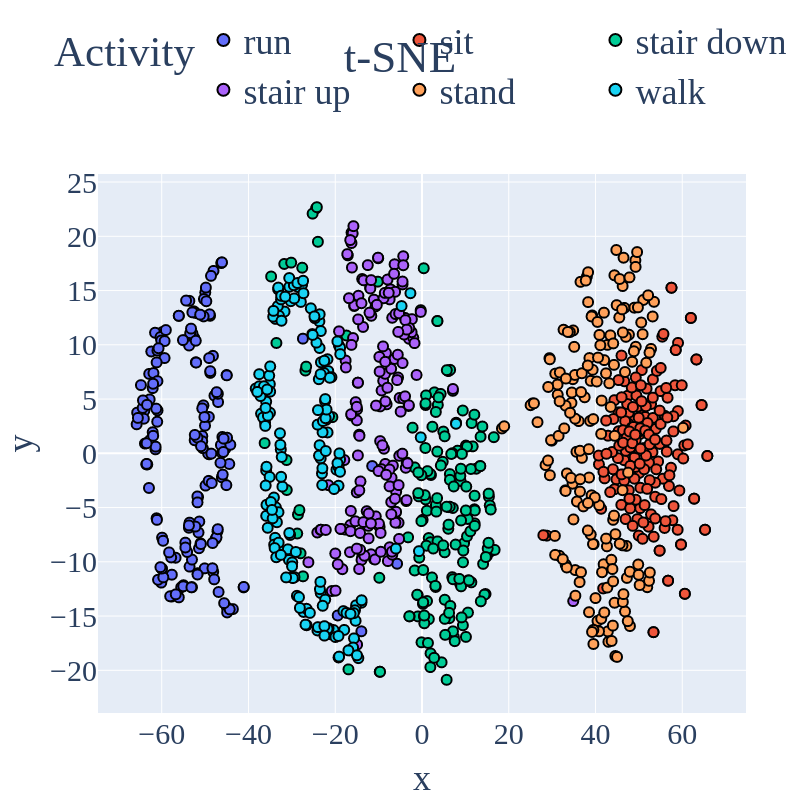

In [265]:
from IPython.display import Image, display
import os

for root, dirs, files in os.walk(log_dir):
    for f in files:
        if f.endswith(".png"):
            p = os.path.join(root, f)
            print(f"Found: {p}")
            display(Image(filename=p))


## 15. Results

In [266]:
metrics = results.get("classification", {})
print(f"{'Metric':<12} {'Value':>8}")
print("-" * 22)
for name, values in metrics.items():
    print(f"{name:<12} {values[0]:>8.4f}")

Metric          Value
----------------------
accuracy       0.9746
